# Problem 2 

In [22]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Velocity field

These functions define the incompressible Taylor–Green-type velocity field.

In [23]:
# ---------------- VELOCITIES ----------------
def u(x, y):
    return -U0 * np.sin(np.pi * x) * np.cos(np.pi * y)

def v(x, y):
    return U0 * np.cos(np.pi * x) * np.sin(np.pi * y)

## 2. Boundary conditions

The left and right walls use Dirichlet temperature conditions, while the top and bottom walls are adiabatic.


In [24]:
# ---------------- BOUNDARY CONDITIONS ----------------
def apply_bc(T, Nx, Ny):
    # West wall: Dirichlet T = T_left
    T[1:Ny+1, 0] = 2.0 * T_left - T[1:Ny+1, 1]

    # East wall: Dirichlet T = T_right
    T[1:Ny+1, Nx+1] = 2.0 * T_right - T[1:Ny+1, Nx]

    # South wall: adiabatic dT/dy = 0
    T[0, :] = T[1, :]

    # North wall: adiabatic dT/dy = 0
    T[Ny+1, :] = T[Ny, :]


## 3. Global parameters

This is changable according to the requirements


In [25]:
# ---------------- GLOBAL PARAMETERS ----------------
alpha = 1.0e-3
U0 = 1.0
T_left = 1.0
T_right = 0.0
Lx = Ly = 1.0

# Run settings
N_single = 20
N_multiple = [20, 40, 60, 80]

mode = "multiple"      # choose: "single" or "multiple"

# Solver method selector:
# implemented: "explicit_upwind"
# placeholders left open: "backward_euler", "crank_nicolson"
method = "explicit_upwind"

## 4. Solver

The `method` variable chooses the time integration or discretization option.

In [26]:
def solver(N, method):
    Nx = Ny = N
    dx = Lx / Nx
    dy = Ly / Ny

    x = np.linspace(0.5 * dx, Lx - 0.5 * dx, Nx)
    y = np.linspace(0.5 * dy, Ly - 0.5 * dy, Ny)
    X, Y = np.meshgrid(x, y)

    # cell-centered velocity, only for quiver plot
    u_cells = -U0 * np.sin(np.pi * X) * np.cos(np.pi * Y)
    v_cells =  U0 * np.cos(np.pi * X) * np.sin(np.pi * Y)

    T = np.full((Ny + 2, Nx + 2), T_right)

    # ---------------- INITIAL CONDITION ----------------
    print("-- Initial conditions")
    T[:, :] = T_right
    apply_bc(T, Nx, Ny)

    # Stable explicit time step estimate
    dt = 1.0 / ((U0 / dx + U0 / dy) + (2.0 * alpha * (1.0 / dx**2 + 1.0 / dy**2)))

    tol = 1e-6
    err = 1.0
    t = 0.0
    it = 0
    it_max = 500000

    err_hist = []
    time_hist = []

    # indices nearest to x=0.5 and y=0.5
    i_mid = np.argmin(np.abs(x - 0.5)) + 1
    j_mid = np.argmin(np.abs(y - 0.5)) + 1

    # ---------------- TIME LOOP ----------------
    while err > tol and it < it_max:
        T_old = T.copy()

        if method == "explicit_upwind":
            for j in range(1, Ny + 1):
                yj = (j - 0.5) * dy
                y_n = j * dy
                y_s = (j - 1) * dy

                for i in range(1, Nx + 1):
                    xi = (i - 0.5) * dx
                    x_e = i * dx
                    x_w = (i - 1) * dx

                    # face velocities evaluated analytically
                    ue = u(x_e, yj)
                    uw = u(x_w, yj)
                    vn = v(xi, y_n)
                    vs = v(xi, y_s)

                    Tp = T_old[j, i]
                    Te_cell = T_old[j, i + 1]
                    Tw_cell = T_old[j, i - 1]
                    Tn_cell = T_old[j + 1, i]
                    Ts_cell = T_old[j - 1, i]

                    # first-order upwind face temperatures
                    Te = Tp      if ue > 0.0 else Te_cell
                    Tw = Tw_cell if uw > 0.0 else Tp
                    Tn = Tp      if vn > 0.0 else Tn_cell
                    Ts = Ts_cell if vs > 0.0 else Tp

                    conv_x = (ue * Te - uw * Tw) / dx
                    conv_y = (vn * Tn - vs * Ts) / dy

                    diff_x = alpha * (Te_cell - 2.0 * Tp + Tw_cell) / dx**2
                    diff_y = alpha * (Tn_cell - 2.0 * Tp + Ts_cell) / dy**2

                    T[j, i] = Tp + dt * (-(conv_x + conv_y) + diff_x + diff_y)

            apply_bc(T, Nx, Ny)

        elif method == "backward_euler":
            raise NotImplementedError(
                "Method 'backward_euler' is not implemented yet. Add it here when ready."
            )

        elif method == "crank_nicolson":
            raise NotImplementedError(
                "Method 'crank_nicolson' is not implemented yet. Add it here when ready."
            )

        else:
            raise ValueError(f"Unknown method '{method}'.")

        err = np.max(np.abs(T - T_old))
        t += dt
        it += 1

        err_hist.append(err)
        time_hist.append(t)

        if it % 500 == 0:
            print(f"it = {it:6d}, t = {t:10.5f}, err = {err:.3e}")

    print(f"\nReached steady state at about t = {t:.5f}")
    print(f"Final err = {err:.3e}, iterations = {it}")

    return {
        "T": T,
        "uc": u_cells,
        "vc": v_cells,
        "N": N,
        "x": x,
        "y": y,
        "X": X,
        "Y": Y,
        "i_mid": i_mid,
        "j_mid": j_mid,
        "err": err,
        "it": it,
        "t": t,
        "err_hist": err_hist,
        "time_hist": time_hist,
        "method": method
    }


## 5. Run the selected case

This cell runs either a single-grid case or a multi-grid study, depending on the `mode` setting above.


In [27]:
results_single = {}
results = {}

if mode == "single":
    results_single = solver(N_single, method=method)

elif mode == "multiple":
    for N in N_multiple:
        print(f"Running N = {N}")
        results[N] = solver(N, method=method)
        print(f"   iterations = {results[N]['it']}, final err = {results[N]['err']:.3e}")

else:
    raise ValueError("mode must be either 'single' or 'multiple'")


Running N = 20
-- Initial conditions
it =    500, t =   12.01923, err = 4.091e-04
it =   1000, t =   24.03846, err = 2.426e-04
it =   1500, t =   36.05769, err = 1.355e-04
it =   2000, t =   48.07692, err = 7.563e-05
it =   2500, t =   60.09615, err = 4.220e-05
it =   3000, t =   72.11538, err = 2.355e-05
it =   3500, t =   84.13462, err = 1.314e-05
it =   4000, t =   96.15385, err = 7.332e-06
it =   4500, t =  108.17308, err = 4.091e-06
it =   5000, t =  120.19231, err = 2.283e-06
it =   5500, t =  132.21154, err = 1.274e-06

Reached steady state at about t = 137.21154
Final err = 9.994e-07, iterations = 5708
   iterations = 5708, final err = 9.994e-07
Running N = 40
-- Initial conditions
it =    500, t =    5.78704, err = 4.275e-04
it =   1000, t =   11.57407, err = 1.774e-04
it =   1500, t =   17.36111, err = 1.628e-04
it =   2000, t =   23.14815, err = 1.347e-04
it =   2500, t =   28.93519, err = 1.067e-04
it =   3000, t =   34.72222, err = 8.347e-05
it =   3500, t =   40.50926, er

## 6. Plots for the single-grid case

These figures correspond to the steady-state temperature field, the stationarity history, and the two centreline profiles.


In [28]:
if mode == "single":
    plt.figure()
    plt.imshow(
        results_single["T"][1:-1, 1:-1],
        origin="lower",
        extent=[0.0, Lx, 0.0, Ly],
        cmap="inferno",
        aspect="equal",
    )
    plt.quiver(results_single["X"], results_single["Y"], results_single["uc"], results_single["vc"], color="white")
    plt.colorbar(label="T")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"Steady-state temperature field ({results_single['method']}), "
        f"t ≈ {results_single['t']:.3f}"
    )
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.semilogy(results_single["time_hist"], results_single["err_hist"])
    plt.xlabel("t")
    plt.ylabel(r"$\max |T^{n+1}-T^n|$")
    plt.title("Steady-state criterion")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(
        results_single["x"],
        (results_single["T"][results_single["j_mid"], 1:-1] + results_single["T"][results_single["j_mid"]-1, 1:-1]) / 2,
        marker="o"
    )
    plt.xlabel("x")
    plt.ylabel("T")
    plt.title(
        f"Centreline profile: T(x, y={((results_single['y'][results_single['j_mid']-1] + results_single['y'][results_single['j_mid']-2]) / 2):.3f})"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(
        results_single["y"],
        (results_single["T"][1:-1, results_single["i_mid"]] + results_single["T"][1:-1, results_single["i_mid"]-1]) / 2,
        marker="o"
    )
    plt.xlabel("y")
    plt.ylabel("T")
    plt.title(
        f"Centreline profile: T(x={((results_single['x'][results_single['i_mid']-1] + results_single['x'][results_single['i_mid']-2]) / 2):.3f}, y)"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 7. Plots for the grid-convergence study

If `mode = "multiple"`, this cell plots the two centreline profiles for all resolutions.


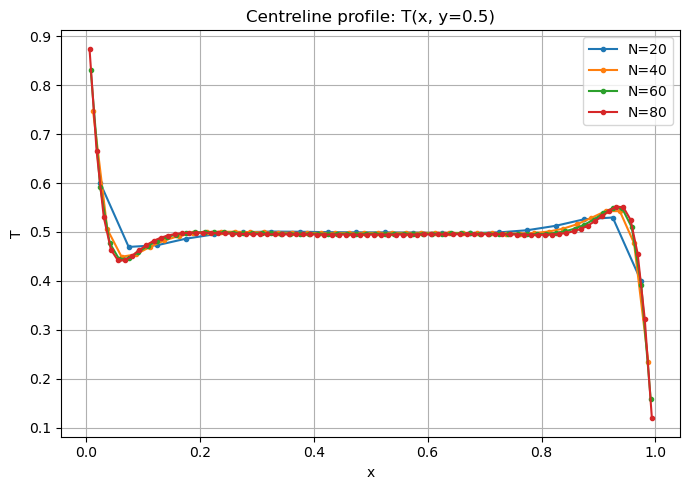

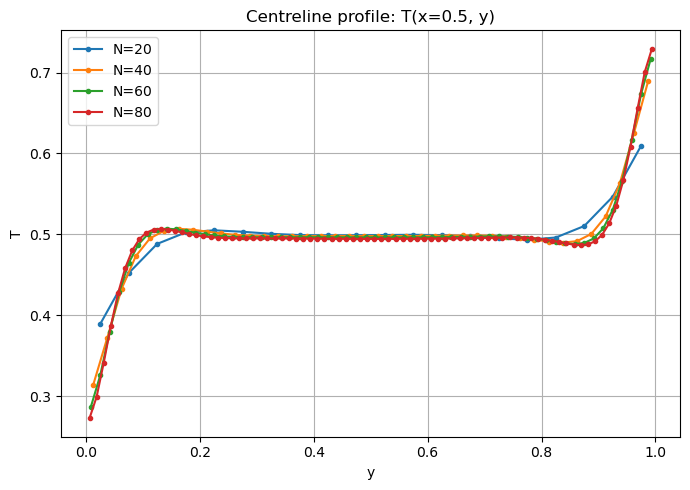

In [29]:
if mode == "multiple":
    plt.figure(figsize=(7, 5))
    for N in N_multiple:
        plt.plot(
            results[N]["x"],
            (results[N]["T"][results[N]["j_mid"], 1:-1] + results[N]["T"][results[N]["j_mid"]-1, 1:-1]) / 2,
            marker="o",
            ms=3,
            label=f"N={N}"
        )
    plt.xlabel("x")
    plt.ylabel("T")
    plt.title("Centreline profile: T(x, y=0.5)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    for N in N_multiple:
        plt.plot(
            results[N]["y"],
            (results[N]["T"][1:-1, results[N]["i_mid"]] + results[N]["T"][1:-1, results[N]["i_mid"]-1]) / 2,
            marker="o",
            ms=3,
            label=f"N={N}"
        )
    plt.xlabel("y")
    plt.ylabel("T")
    plt.title("Centreline profile: T(x=0.5, y)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()